## Congressional Trade Performance Analysis

This project is about analyzing disclosed stock trades made by U.S. politicians and comparing their performance against the S&P 500.

The data comes from public congressional trading disclosures and historical stock price data. Python will be used to clean the trades, match them with stock prices, calculate returns after each trade, and compare those returns with the market benchmark.

The goal of this project is to examine whether disclosed politician trades appear to outperform the S&P 500 after the reported trade date.

An AI API will be used after the calculations are finished. Given the calculated trade-performance results, the API will classify top trades into strong outperformance, moderate outperformance, weak or no outperformance, and underperformance. It will also explain the main patterns and limitations in plain language.




How to use this notebook

This notebook analyzes disclosed U.S. congressional stock trades from 2023 and compares their 30-day and 90-day performance against the S&P 500.

To run the notebook, keep the following files in the `Data files` folder:

- `congress_trades.csv`
- `stock_prices_2023_to_now.csv`
- `sp500_index.csv`

The notebook also uses the Gemini API for the AI analysis section. Store the API key in a local `.env` file:

```text
GEMINI_API_KEY=your_key_here
```

## Data pipeline

The diagram below shows how the project moves from the raw datasets to calculated trade results and AI-assisted interpretation.


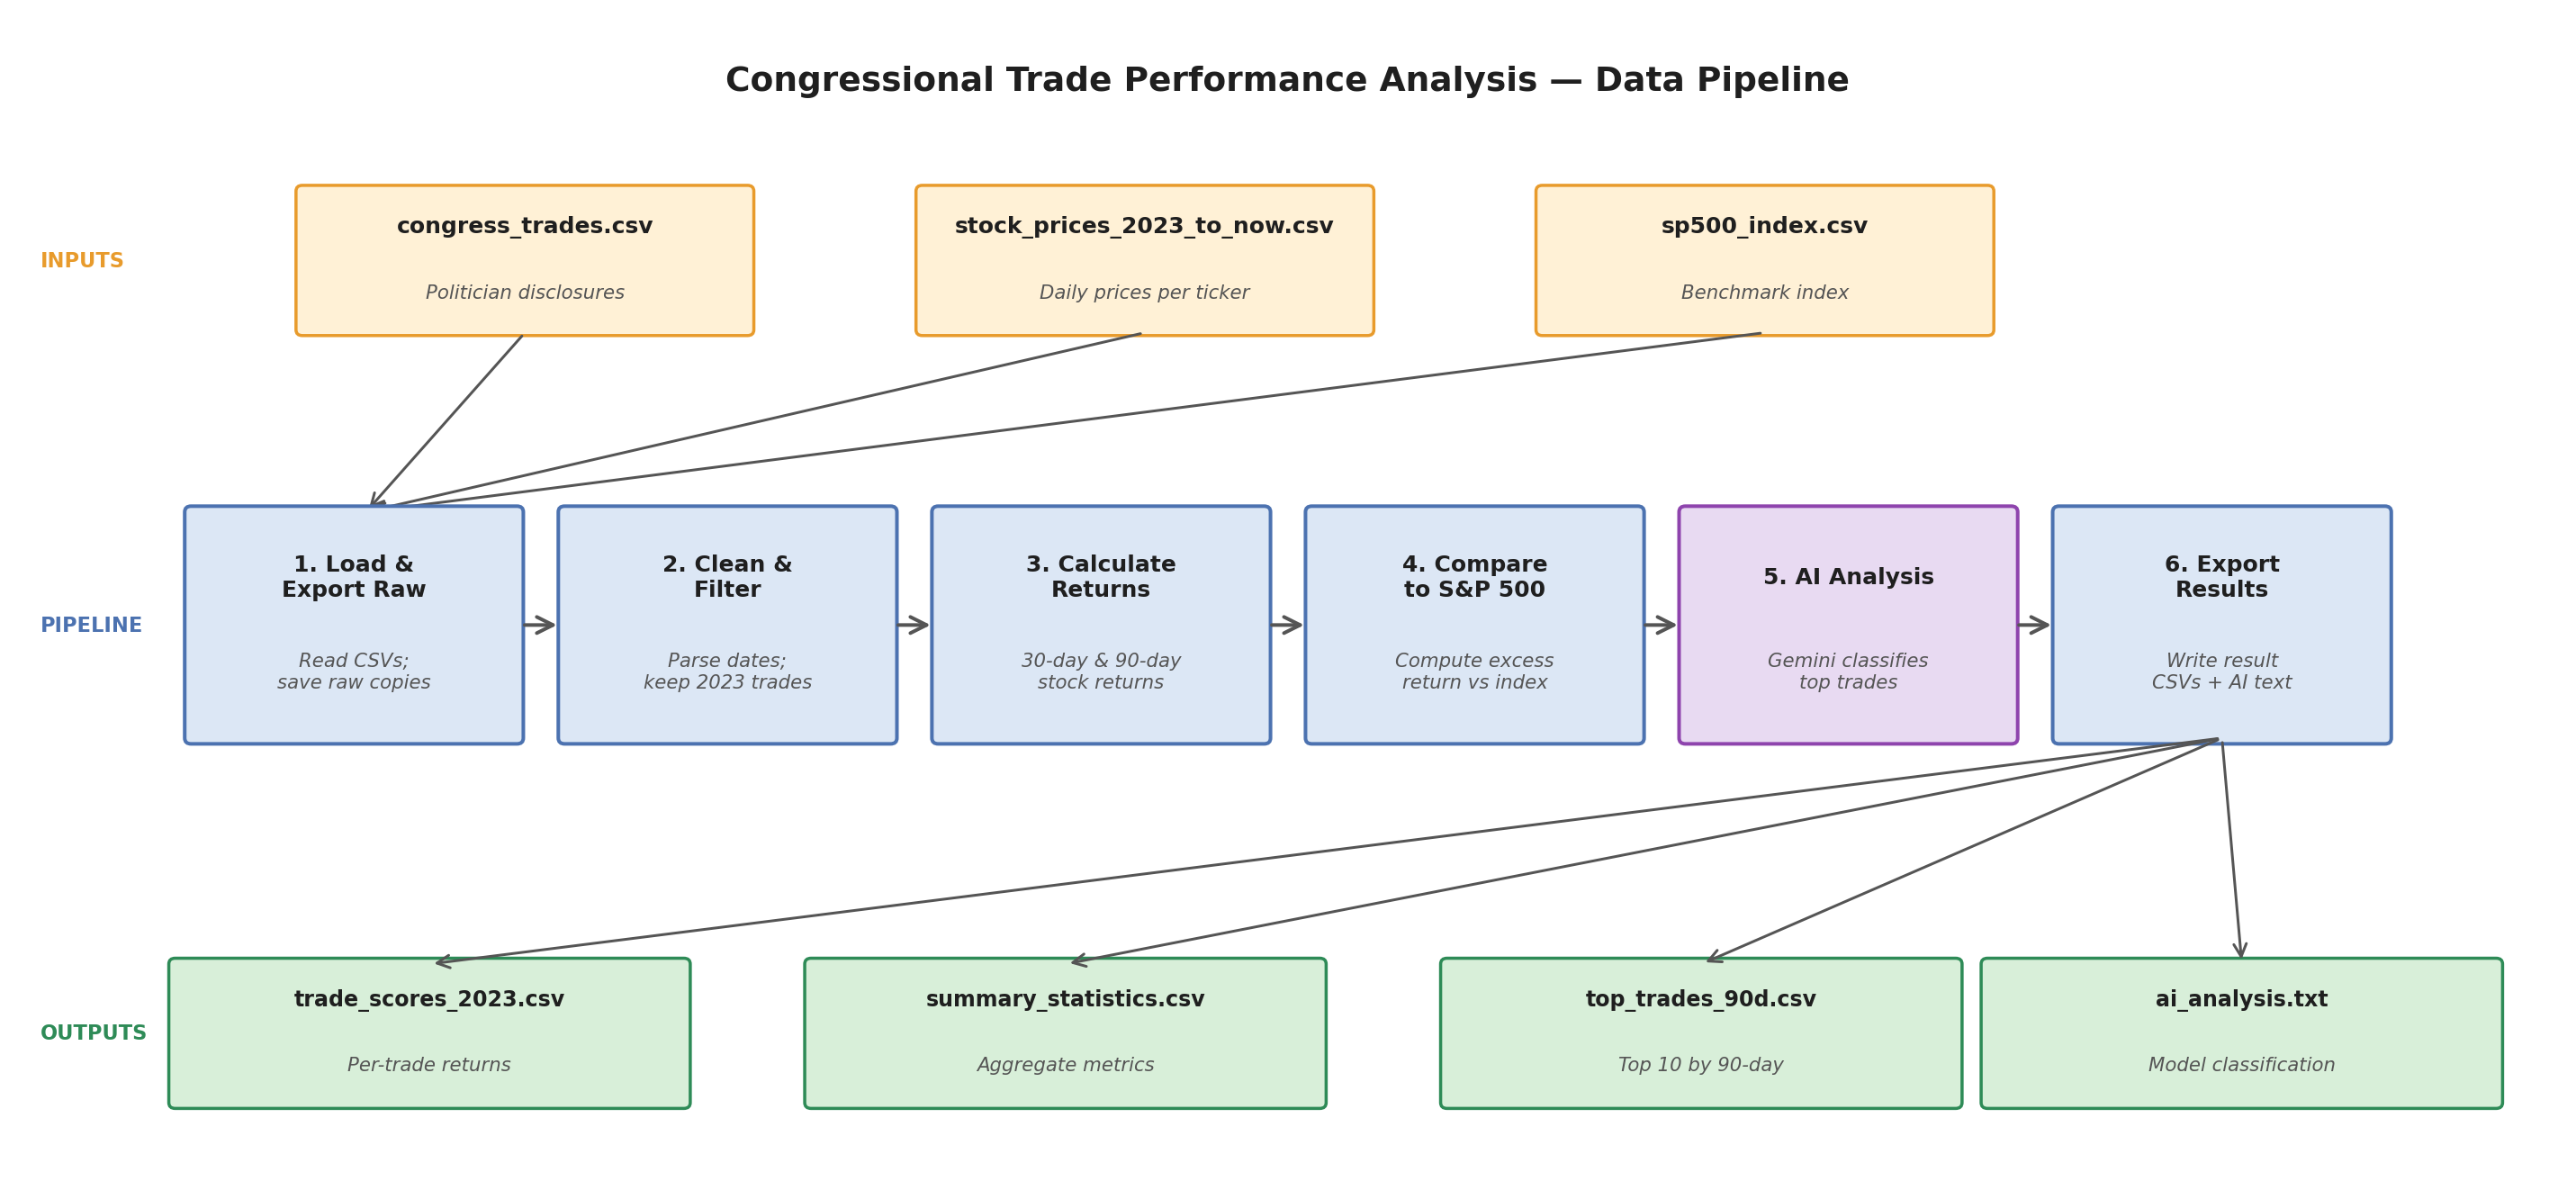

In [2]:
from pathlib import Path
from IPython.display import Image, display

image_path = Path("Results/pipeline_diagram.png")

if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print("Pipeline diagram not found.")
    print("Expected file:", image_path)
    print("Current folder:", Path.cwd())


## Loading the data

In [3]:
import pandas as pd
from pathlib import Path

data_folder = Path("Data files")
processed_folder = Path("Processed data")
results_folder = Path("Results")

processed_folder.mkdir(exist_ok=True)
results_folder.mkdir(exist_ok=True)

print("Current folder:", Path.cwd())
print("Looking for files in:", data_folder)
print(list(data_folder.iterdir()))

trades_raw = pd.read_csv(data_folder / "congress_trades.csv", encoding="cp1252")
prices_raw = pd.read_csv(data_folder / "stock_prices_2023_to_now.csv")
sp500_raw = pd.read_csv(data_folder / "sp500_index.csv")

trades_raw.to_csv(processed_folder / "raw_congress_trades.csv", index=False)
prices_raw.to_csv(processed_folder / "raw_stock_prices.csv", index=False)
sp500_raw.to_csv(processed_folder / "raw_sp500_index.csv", index=False)

display(trades_raw.head())
display(prices_raw.head())
display(sp500_raw.head())

print("Congressional trades rows:", len(trades_raw))
print("Stock price rows:", len(prices_raw))
print("S&P 500 rows:", len(sp500_raw))


Current folder: C:\Users\jocke\project
Looking for files in: Data files
[WindowsPath('Data files/congress_trades.csv'), WindowsPath('Data files/sp500_index.csv'), WindowsPath('Data files/stock_prices_2023_to_now.csv')]


,Ticker,TickerType,Company,Traded,Transaction,Trade_Size_USD,Status,Subholding,Description,Name,Filed,Party,District,Chamber,Comments,Quiver_Upload_Time,excess_return,State,last_modified
0,NGL,ST,NGL ENERGY PARTNERS LP COMMON UNITS REPRESENTI...,"Monday, March 11, 2024",Sale,"$15,001 - $50,000",NEW,EQUITABLE RETIREMENT ACCOUNT,NaN,Mark Dr Green,2024-03-13,R,TN07,House,NaN,2024-03-14,1.523296,Tennessee,2024-03-14
1,FCX,ST,"FREEPORT-MCMORAN, INC. COMMON STOCK","Thursday, February 29, 2024",Sale,"$1,001 - $15,000",NEW,MORGAN STANLEY - SELECT UMA ACCOUNT # 1,NaN,Josh Gottheimer,2024-03-07,D,NJ05,House,NaN,2024-03-08,17.325032,New Jersey,2024-03-08
2,V,ST,VISA INC.,"Thursday, February 29, 2024",Purchase,"$1,001 - $15,000",NEW,TRUST ONE,NaN,Pete Sessions,2024-03-07,R,TX17,House,NaN,2024-03-08,-0.518105,Texas,2024-03-08
3,APPLE INC. (XNAS:AAPL),ST,APPLE INC. - COMMON STOCK,"Thursday, February 29, 2024",Purchase,$360.00,NEW,IRA ONE,NaN,Pete Sessions,2024-02-29,R,TX17,House,NaN,2024-03-01,-5.157553,Texas,2024-03-01
4,MSFT,ST,MICROSOFT CORPORATION - COMMON STOCK,"Thursday, February 29, 2024",Sale,"$100,001 - $250,000",NEW,NaN,VESTED SHARES SOLD TO SEPARATE TRUST NOT FOR T...,Suzan K. Delbene,2024-03-08,D,WA01,House,NaN,2024-03-11,0.012454,Washington,2024-03-11


,Date,Ticker,Close
0,2023-01-03,AAGIY,45.799999
1,2023-01-03,AAP,151.539993
2,2023-01-03,AAPL,125.070000
3,2023-01-03,ABBV,162.380005
4,2023-01-03,ABNB,84.900002


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


Congressional trades rows: 46467
Stock price rows: 187126
S&P 500 rows: 2517


In [4]:
# If needed, the saved raw data can be loaded with:
# trades_raw = pd.read_csv("Processed data/raw_congress_trades.csv")
# prices_raw = pd.read_csv("Processed data/raw_stock_prices.csv")
# sp500_raw = pd.read_csv("Processed data/raw_sp500_index.csv")


## Cleaning and filtering data

In [5]:
trades = trades_raw.copy()
prices = prices_raw.copy()
sp500 = sp500_raw.copy()

trades["traded_date"] = pd.to_datetime(trades["Traded"], errors="coerce")
trades["filed_date"] = pd.to_datetime(trades["Filed"], errors="coerce")
prices["Date"] = pd.to_datetime(prices["Date"], errors="coerce")
sp500["Date"] = pd.to_datetime(sp500["Date"], errors="coerce")

trades["ticker_clean"] = trades["Ticker"].astype(str).str.upper().str.strip()
prices["ticker_clean"] = prices["Ticker"].astype(str).str.upper().str.strip()

valid_transactions = ["Purchase", "Sale", "Sale (Full)", "Sale (Partial)"]

trades_2023 = trades[
    (trades["Transaction"].isin(valid_transactions)) &
    (trades["traded_date"] >= "2023-01-01") &
    (trades["traded_date"] <= "2023-12-31")
].copy()

available_tickers = set(prices["ticker_clean"].dropna().unique())

trades_2023 = trades_2023[
    trades_2023["ticker_clean"].isin(available_tickers)
].copy()

display(trades_2023.head())

print("Trades after filtering:", len(trades_2023))
print("Unique politicians:", trades_2023["Name"].nunique())
print("Unique tickers:", trades_2023["ticker_clean"].nunique())
print("Date range:", trades_2023["traded_date"].min(), "to", trades_2023["traded_date"].max())


,Ticker,TickerType,Company,Traded,Transaction,Trade_Size_USD,Status,Subholding,Description,Name,...,District,Chamber,Comments,Quiver_Upload_Time,excess_return,State,last_modified,traded_date,filed_date,ticker_clean
439,DVN,ST,DEVON ENERGY CORPORATION,"Friday, December 29, 2023",Purchase,"$1,001 - $15,000",NEW,HERN FAMILY FOUNDATION,DIVIDEND REINVESTMENT,Kevin Hern,...,OK01,House,NaN,2024-01-15,-2.481609,Oklahoma,2024-01-15,2023-12-29,2024-01-13,DVN
440,TFC,Stock,Truist Financial Corp,"Friday, December 29, 2023",Sale (Partial),"$15,001 - $50,000",New,NaN,NaN,"Capito, Shelley Moore",...,NaN,Senate,NaN,2024-01-12,-13.182654,West Virginia,2024-01-12,2023-12-29,2024-01-12,TFC
441,NOC,ST,NORTHROP GRUMMAN CORPORATION,"Friday, December 29, 2023",Purchase,"$15,001 - $50,000",NEW,MORGAN STANLEY - SELECT UMA ACCOUNT # 1,NaN,Josh Gottheimer,...,NJ05,House,NaN,2024-01-09,-8.967998,New Jersey,2024-01-09,2023-12-29,2024-01-07,NOC
442,SCHW,ST,CHARLES SCHWAB CORPORATION,"Friday, December 29, 2023",Sale,"$50,001 - $100,000",NEW,HILL 2012 TRUST (FORMERLY JAY F HILL TRUST),NaN,James French Hill,...,AR02,House,NaN,2024-01-11,-10.161162,Arkansas,2024-01-11,2023-12-29,2024-01-10,SCHW
443,PYPL,ST,"PAYPAL HOLDINGS, INC.","Friday, December 29, 2023",Sale,"$15,001 - $50,000",NEW,HILL 2012 TRUST (FORMERLY JAY F HILL TRUST),NaN,James French Hill,...,AR02,House,NaN,2024-01-11,-5.258127,Arkansas,2024-01-11,2023-12-29,2024-01-10,PYPL


Trades after filtering: 2970
Unique politicians: 68
Unique tickers: 485
Date range: 2023-01-03 00:00:00 to 2023-12-29 00:00:00


## Calculating trade returns

This section calculates 30-day and 90-day excess returns for each trade.

For purchases, a positive excess return means the stock beat the S&P 500 after the trade. For sales, a positive excess return means the stock performed worse than the S&P 500 after the sale, so the sale avoided underperformance compared with holding the stock.


In [6]:
prices = prices.sort_values(["ticker_clean", "Date"])
sp500 = sp500.sort_values("Date")

price_by_ticker = {
    ticker: group.sort_values("Date")
    for ticker, group in prices.groupby("ticker_clean")
}

def get_next_stock_price(ticker, target_date):
    ticker_prices = price_by_ticker.get(ticker)
    
    if ticker_prices is None:
        return None
    
    rows = ticker_prices[ticker_prices["Date"] >= target_date]
    
    if rows.empty:
        return None
    
    return rows.iloc[0]["Close"]

def get_next_sp500_value(target_date):
    rows = sp500[sp500["Date"] >= target_date]
    
    if rows.empty:
        return None
    
    return rows.iloc[0]["S&P500"]

def calculate_trade_score(row, days_after):
    trade_date = row["traded_date"]
    future_date = trade_date + pd.Timedelta(days=days_after)
    ticker = row["ticker_clean"]
    
    stock_start = get_next_stock_price(ticker, trade_date)
    stock_end = get_next_stock_price(ticker, future_date)
    sp500_start = get_next_sp500_value(trade_date)
    sp500_end = get_next_sp500_value(future_date)
    
    if stock_start is None or stock_end is None or sp500_start is None or sp500_end is None:
        return None
    
    stock_return = (stock_end / stock_start) - 1
    sp500_return = (sp500_end / sp500_start) - 1
    
    if row["Transaction"] == "Purchase":
        excess_return = stock_return - sp500_return
    else:
        excess_return = sp500_return - stock_return
    
    return excess_return * 100

trade_scores = trades_2023.copy()

print("Calculating 30-day returns...")
trade_scores["excess_return_30d"] = trade_scores.apply(
    lambda row: calculate_trade_score(row, 30),
    axis=1
)

print("Calculating 90-day returns...")
trade_scores["excess_return_90d"] = trade_scores.apply(
    lambda row: calculate_trade_score(row, 90),
    axis=1
)

trade_scores = trade_scores.dropna(
    subset=["excess_return_30d", "excess_return_90d"]
).copy()

trade_scores["good_trade_30d"] = trade_scores["excess_return_30d"] > 0
trade_scores["good_trade_90d"] = trade_scores["excess_return_90d"] > 0

display(trade_scores[[
    "Name", "Ticker", "Transaction", "traded_date",
    "excess_return_30d", "excess_return_90d",
    "good_trade_30d", "good_trade_90d"
]].head())

print("Trades with calculated returns:", len(trade_scores))
print("30-day good trade rate:", trade_scores["good_trade_30d"].mean())
print("90-day good trade rate:", trade_scores["good_trade_90d"].mean())



Calculating 30-day returns...
Calculating 90-day returns...


,Name,Ticker,Transaction,traded_date,excess_return_30d,excess_return_90d,good_trade_30d,good_trade_90d
439,Kevin Hern,DVN,Purchase,2023-12-29,-8.899570,0.614615,False,True
440,"Capito, Shelley Moore",TFC,Sale (Partial),2023-12-29,0.145564,4.578378,True,True
441,Josh Gottheimer,NOC,Purchase,2023-12-29,-9.686612,-7.910825,False,False
442,James French Hill,SCHW,Sale,2023-12-29,10.378543,5.012675,True,True
443,James French Hill,PYPL,Sale,2023-12-29,-0.512152,1.071549,False,True


Trades with calculated returns: 2970
30-day good trade rate: 0.5033670033670034
90-day good trade rate: 0.5043771043771044


## Summary statistics

In [7]:
summary_stats = pd.DataFrame({
    "Metric": [
        "Number of trades",
        "30-day good trade rate (%)",
        "90-day good trade rate (%)",
        "Average 30-day excess return (%)",
        "Average 90-day excess return (%)",
        "Median 30-day excess return (%)",
        "Median 90-day excess return (%)"
    ],
    "Value": [
        len(trade_scores),
        trade_scores["good_trade_30d"].mean() * 100,
        trade_scores["good_trade_90d"].mean() * 100,
        trade_scores["excess_return_30d"].mean(),
        trade_scores["excess_return_90d"].mean(),
        trade_scores["excess_return_30d"].median(),
        trade_scores["excess_return_90d"].median()
    ]
})

summary_stats["Value"] = summary_stats["Value"].round(2)

display(summary_stats)

top_trades_90d = (
    trade_scores[
        ["Name", "Ticker", "Transaction", "traded_date", "excess_return_90d"]
    ]
    .sort_values("excess_return_90d", ascending=False)
    .head(10)
)

display(top_trades_90d)


,Metric,Value
0,Number of trades,2970.00
1,30-day good trade rate (%),50.34
2,90-day good trade rate (%),50.44
3,Average 30-day excess return (%),-0.15
4,Average 90-day excess return (%),-0.13
5,Median 30-day excess return (%),0.07
6,Median 90-day excess return (%),0.12


,Name,Ticker,Transaction,traded_date,excess_return_90d
3392,Daniel Goldman,OPEN,Purchase,2023-04-10,135.546074
699,Pete Sessions,NVDA,Purchase,2023-12-06,77.284537
3941,Daniel Goldman,NVDA,Purchase,2023-03-01,70.284603
1458,Josh Gottheimer,ARQT,Sale,2023-09-15,68.751587
3962,Josh Gottheimer,NVDA,Purchase,2023-02-27,65.070953
3233,Jonathan Jackson,NVDA,Purchase,2023-04-14,62.824957
4424,Josh Gottheimer,META,Purchase,2023-01-31,61.002039
3750,Morgan Mcgarvey,NVDA,Purchase,2023-03-07,60.992445
3759,Josh Gottheimer,NVDA,Purchase,2023-03-06,60.736100
1104,Josh Gottheimer,ADYEY,Purchase,2023-10-16,59.003050


## Visual analysis

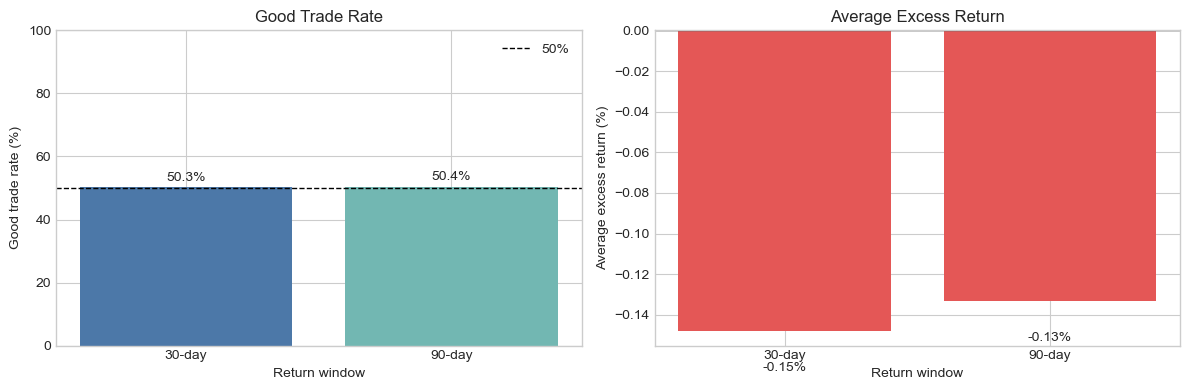

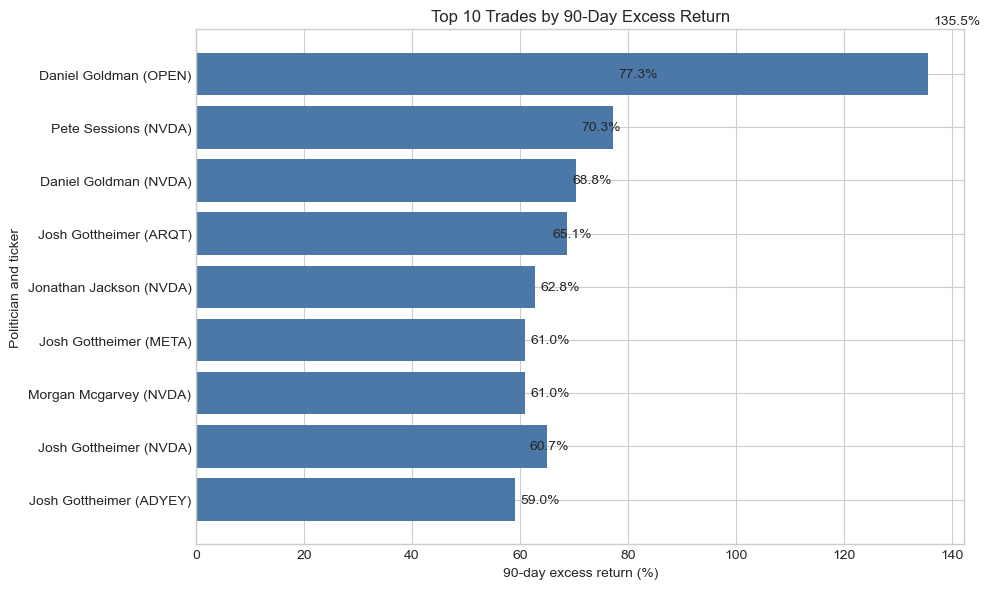

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Data for first two plots
hit_rates = pd.DataFrame({
    "Window": ["30-day", "90-day"],
    "Good trade rate (%)": [
        trade_scores["good_trade_30d"].mean() * 100,
        trade_scores["good_trade_90d"].mean() * 100
    ]
})

avg_returns = pd.DataFrame({
    "Window": ["30-day", "90-day"],
    "Average excess return (%)": [
        trade_scores["excess_return_30d"].mean(),
        trade_scores["excess_return_90d"].mean()
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: good trade rate
axes[0].bar(
    hit_rates["Window"],
    hit_rates["Good trade rate (%)"],
    color=["#4C78A8", "#72B7B2"]
)

axes[0].axhline(50, color="black", linewidth=1, linestyle="--", label="50%")
axes[0].set_title("Good Trade Rate")
axes[0].set_xlabel("Return window")
axes[0].set_ylabel("Good trade rate (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()

for i, value in enumerate(hit_rates["Good trade rate (%)"]):
    axes[0].text(i, value + 2, f"{value:.1f}%", ha="center")


# Plot 2: average excess return
colors = ["#E45756" if value < 0 else "#59A14F" for value in avg_returns["Average excess return (%)"]]

axes[1].bar(
    avg_returns["Window"],
    avg_returns["Average excess return (%)"],
    color=colors
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Average Excess Return")
axes[1].set_xlabel("Return window")
axes[1].set_ylabel("Average excess return (%)")

for i, value in enumerate(avg_returns["Average excess return (%)"]):
    label_position = value - 0.02 if value < 0 else value + 0.02
    axes[1].text(i, label_position, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()


# Plot 3: top 10 trades by 90-day excess return
top_plot = top_trades_90d.copy()
top_plot["Label"] = top_plot["Name"] + " (" + top_plot["Ticker"] + ")"
top_plot = top_plot.sort_values("excess_return_90d")

plt.figure(figsize=(10, 6))
plt.barh(top_plot["Label"], top_plot["excess_return_90d"], color="#4C78A8")
plt.title("Top 10 Trades by 90-Day Excess Return")
plt.xlabel("90-day excess return (%)")
plt.ylabel("Politician and ticker")

for i, value in enumerate(top_plot["excess_return_90d"]):
    plt.text(value + 1, i, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()


## AI api analysis

In [9]:
from dotenv import load_dotenv
import os

load_dotenv()

gemini_key = os.getenv("GEMINI_API_KEY")

print("Was GEMINI_API_KEY loaded?", gemini_key is not None)


Was GEMINI_API_KEY loaded? True


## If needed, install once:
!pip install pandas matplotlib python-dotenv google-genai


In [10]:
import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

ai_input_trades = (
    trade_scores[
        [
            "Name",
            "Ticker",
            "Transaction",
            "traded_date",
            "excess_return_30d",
            "excess_return_90d"
        ]
    ]
    .sort_values("excess_return_90d", ascending=False)
    .head(10)
)

ai_input_text = ai_input_trades.to_string(index=False)

if api_key:
    client = genai.Client(api_key=api_key)

    prompt = f"""
Classify each trade below based on both its calculated 30-day and 90-day excess returns.

In this notebook, excess return means performance compared with the S&P 500 over the same period.

Use these exact thresholds for each return window:
- strong outperformance: 50% or higher
- moderate outperformance: 10% to 49.99%
- weak/no outperformance: -5% to 9.99%
- underperformance: below -5%

For each trade, classify both the 30-day result and the 90-day result.
Then briefly explain whether the strongest trades look consistently strong across both windows or mainly strong only at 90 days.

After classifying the trades, add 2-3 short limitations of this analysis.
Do not invent numbers or claim insider trading occurred.

Data:
{ai_input_text}
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    ai_analysis = response.text
else:
    ai_analysis = "Gemini API was not called because GEMINI_API_KEY was not found."

print(ai_analysis)

Path("Results").mkdir(exist_ok=True)

with open("Results/ai_analysis.txt", "w", encoding="utf-8") as file:
    file.write(ai_analysis)


Here's a classification of each trade based on its 30-day and 90-day excess returns, followed by an explanation and limitations:

**Classification of Trades:**

| Name            | Ticker | Transaction | traded_date | excess_return_30d | Classification_30d      | excess_return_90d | Classification_90d      |
| :-------------- | :----- | :---------- | :---------- | :---------------- | :---------------------- | :---------------- | :---------------------- |
| Daniel Goldman  | OPEN   | Purchase    | 2023-04-10  | 24.31%            | moderate outperformance | 135.55%           | strong outperformance   |
| Pete Sessions   | NVDA   | Purchase    | 2023-12-06  | 4.65%             | weak/no outperformance  | 77.28%            | strong outperformance   |
| Daniel Goldman  | NVDA   | Purchase    | 2023-03-01  | 18.38%            | moderate outperformance | 70.28%            | strong outperformance   |
| Josh Gottheimer | ARQT   | Sale        | 2023-09-15  | 43.14%            | moderate outperfo

## Export results

In [11]:
from pathlib import Path

results_folder = Path("Results")
results_folder.mkdir(exist_ok=True)

trade_scores.to_csv(results_folder / "trade_scores_2023.csv", index=False)
summary_stats.to_csv(results_folder / "summary_statistics.csv", index=False)
top_trades_90d.to_csv(results_folder / "top_trades_90d.csv", index=False)

with open(results_folder / "ai_analysis.txt", "w", encoding="utf-8") as file:
    file.write(ai_analysis)

print("Results exported successfully.")
print("Files created in:", results_folder)


Results exported successfully.
Files created in: Results


## Conclusion

The analysis found that the filtered 2023 congressional trades performed very close to the S&P 500 benchmark overall. About 50% of trades were classified as good trades in both the 30-day and 90-day return windows.

The average excess return was slightly negative, while the median excess return was slightly positive. This suggests that most trades were close to the benchmark, but some worse-performing trades pulled the average down.

The strongest individual 90-day trades showed large outperformance, especially trades involving tickers such as OPEN, NVDA, META, and ARQT. However, the AI analysis showed that these trades were usually stronger at 90 days than at 30 days, meaning that the strongest performance often appeared later.

There are important limitations. The project only includes 2023 trades where matching stock price data was available. It does not include exact trade sizes, transaction costs, taxes, full portfolios, or the reasons why the trades were made. Because of this, the results should not be interpreted as proof of insider trading or wrongdoing.


## Statement of AI use

AI was used to help plan the project structure, troubleshoot code, and improve explanations. The Gemini API was used inside the notebook to classify the top trades based on the calculated 30-day and 90-day excess returns.

The AI was not used to generate fake data or calculate the trade returns. The return calculations, filtering, visualizations, and summary statistics were produced with Python using the congressional trading dataset, stock price data, and S&P 500 benchmark data.

